# Chapter 6 — Determinants and Inverses

Chapter 5 left a question dangling. A square system $A\mathbf{x} = \mathbf{b}$
has exactly one solution for every $\mathbf{b}$ precisely when the map destroys
nothing, which is to say when the null space is $\{\mathbf{0}\}$. Is there a
single number that tells you whether that is the case?

There is, and you have met it before: the **determinant**. But its usual
introduction, a formula involving alternating signs, memorised and never
questioned, hides what it actually is:

> $\det A$ is the factor by which the transformation $A$ **scales volume**, with
> a sign that records whether it **flipped orientation**. It is zero exactly
> when the map flattens space into something lower-dimensional, which is exactly
> when the map cannot be undone.

This chapter measures that claim rather than asserting it, builds the inverse
from the elimination you already wrote, and then makes an argument that most
courses skip: **the determinant is a poor tool for the job people usually reach
for it for**, and the number you actually want is the *condition number*.

| Module | What you build | Data |
|---|---|---|
| I | Determinant as a **volume scale factor**, measured by Monte Carlo | — |
| II | Determinant by **elimination** vs by cofactors: same answer, wildly different cost | — |
| III | The **inverse** via Gauss–Jordan, and the equivalence chain that ends in "invertible" | — |
| IV | Why `solve` beats `inv`, and the **condition number** as an error amplifier | — |
| V | The honest verdict: **`det` is not a singularity detector** | — |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a few seconds on CPU; no data downloads. Assumes Chapters 1–5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — The Determinant Is an Area

## I.a What the number means

🧠 **The intuition.** Take the unit square. Apply $A$. You get a parallelogram.
Its area is $|\det A|$. That is not a consequence of the determinant; it is what
the determinant *is*. In three dimensions the unit cube becomes a
parallelepiped whose volume is $|\det A|$, and the pattern continues upward.

Two things follow immediately. **A determinant of zero means the map flattened space**,
since area zero means the parallelogram is a segment: two dimensions went in,
fewer came out, and information was destroyed. **A negative determinant means
orientation flipped**, with the map turning the plane over like a mirror.

📐 **The math.** For $2 \times 2$,

$$ \det \begin{bmatrix} a & b \\ c & d \end{bmatrix} = ad - bc $$

and in general the determinant is the unique function of the columns that is
linear in each column, changes sign when two columns are swapped, and gives 1
for the identity. Those three properties *force* the formula: the alternating
signs are not a convention, they are the swap rule.

💻 **The code.** Do not take the area claim on faith: scatter points inside the
unit square, transform them, and measure the area of what comes out.

In [2]:
N_PTS = 200_000        # <- knob: Monte Carlo sample size

def measured_area(Amat, n=N_PTS):
    """Area of A(unit square), estimated by hit-or-miss sampling."""
    if abs(np.linalg.det(Amat)) < 1e-12:
        return 0.0                                    # collapsed: zero area
    corners = Amat @ np.array([[0., 1, 1, 0], [0, 0, 1, 1]])   # image of the square
    lo, hi = corners.min(axis=1), corners.max(axis=1)
    box_area = np.prod(hi - lo)
    probe = rng.random((2, n)) * (hi - lo)[:, None] + lo[:, None]   # points in the box
    c = np.linalg.solve(Amat, probe)                  # probe, in the column basis
    inside = np.all((c >= 0) & (c <= 1), axis=0)      # inside the parallelogram?
    return box_area * inside.mean()

tests = {
    "identity":            np.eye(2),
    "scale x2, y×3":       np.array([[2.0, 0.0], [0.0, 3.0]]),
    "rotation 30°":        np.array([[np.cos(np.pi/6), -np.sin(np.pi/6)],
                                     [np.sin(np.pi/6),  np.cos(np.pi/6)]]),
    "shear":               np.array([[1.0, 1.0], [0.0, 1.0]]),
    "reflection":          np.array([[1.0, 0.0], [0.0, -1.0]]),
    "generic":             np.array([[2.0, -1.0], [0.5, 1.0]]),
}

print(f"{'transformation':<18} {'det':>8} {'|det|':>8} {'measured area':>15}")
for name, Mz in tests.items():
    d = np.linalg.det(Mz)
    print(f"{name:<18} {d:>8.3f} {abs(d):>8.3f} {measured_area(Mz):>15.3f}")

transformation          det    |det|   measured area
identity              1.000    1.000           1.000
scale x2, y×3         6.000    6.000           6.000
rotation 30°          1.000    1.000           1.003
shear                 1.000    1.000           1.000
reflection           -1.000    1.000           1.000
generic               2.500    2.500           2.505


Three readings worth pausing on. Rotation has determinant 1, because rotations
move everything and change no areas. Shear has determinant 1 as well, which
surprises people: the parallelogram leans over, but its base and height are
unchanged, so its area is unchanged too. Reflection has determinant $-1$, the
same area with the opposite orientation, and the Monte Carlo estimate can only
ever report $|\det|$, which is exactly why the sign has to be carried by the
algebra.

## I.b The picture, including the collapse

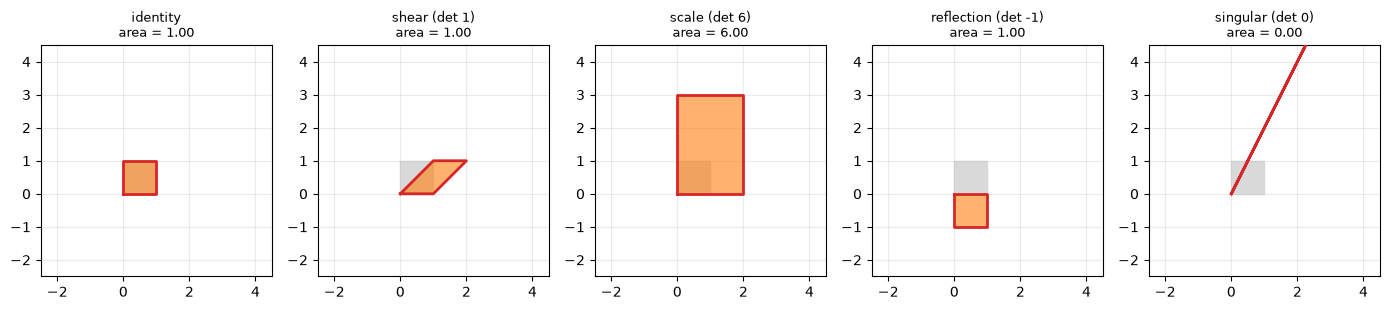

The last square has been flattened onto a line: area 0, det 0, and no way back.


In [3]:
square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
show = [("identity", np.eye(2)),
        ("shear (det 1)", tests["shear"]),
        ("scale (det 6)", tests["scale x2, y×3"]),
        ("reflection (det -1)", tests["reflection"]),
        ("singular (det 0)", np.array([[1.0, 2.0], [2.0, 4.0]]))]

fig, axes = plt.subplots(1, len(show), figsize=(14, 3.0))
for ax, (name, Mz) in zip(axes, show):
    out = Mz @ square
    ax.fill(square[0], square[1], color="0.85", zorder=1)
    ax.fill(out[0], out[1], color="tab:orange", alpha=0.6, zorder=2)
    ax.plot(out[0], out[1], color="tab:red", lw=2, zorder=3)
    ax.set_title(f"{name}\narea = {abs(np.linalg.det(Mz)):.2f}", fontsize=9)
    ax.set_xlim(-2.5, 4.5); ax.set_ylim(-2.5, 4.5); ax.set_aspect("equal"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print("The last square has been flattened onto a line: area 0, det 0, and no way back.")

---
# Module II — Computing It: Two Algorithms, One Answer

## II.a Elimination already knows the determinant

🧠 **The intuition.** You already own the machinery. Elimination, built in
Chapter 5, computes the determinant as a free by-product: every row operation
changes the determinant in a completely predictable way, so keeping a running
tally while you eliminate is the entire algorithm.

📐 **The math.** Watch what row operations do to the determinant:

| Operation | Effect on $\det$ |
|---|---|
| swap two rows | multiply by $-1$ |
| scale a row by $c$ | multiply by $c$ |
| add a multiple of one row to another | **no change** |

Since elimination reduces $A$ to an upper-triangular $U$ using only these, and a
triangular determinant is the product of its diagonal,

$$ \det A = (-1)^{\#\text{swaps}} \prod_i U_{ii} $$

That is $O(n^3)$ work, the same elimination from Chapter 5 with some
bookkeeping added.

💻 **The code.** Both algorithms, from scratch.

In [4]:
def det_by_elimination(M):
    """det via forward elimination with partial pivoting: O(n^3)."""
    U = np.array(M, dtype=float, copy=True)
    n = U.shape[0]
    sign = 1.0
    for col in range(n):
        p = col + int(np.argmax(np.abs(U[col:, col])))
        if abs(U[p, col]) < 1e-15:
            return 0.0                                  # a zero pivot: singular
        if p != col:
            U[[col, p]] = U[[p, col]]; sign = -sign      # each swap flips the sign
        for i in range(col + 1, n):
            U[i, col:] -= (U[i, col] / U[col, col]) * U[col, col:]
    return sign * np.prod(np.diag(U))


def det_by_cofactors(M):
    """det by expansion along the first row: the textbook recursion, O(n!)."""
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    if n == 1:
        return M[0, 0]
    total = 0.0
    for j in range(n):
        minor = np.delete(np.delete(M, 0, axis=0), j, axis=1)
        total += ((-1) ** j) * M[0, j] * det_by_cofactors(minor)
    return total


Atest = rng.normal(size=(6, 6))
print(f"elimination : {det_by_elimination(Atest): .8f}")
print(f"cofactors   : {det_by_cofactors(Atest): .8f}")
print(f"np.linalg.det: {np.linalg.det(Atest): .8f}")

elimination : -85.27008360
cofactors   : -85.27008360
np.linalg.det: -85.27008360


## II.b The cost of the textbook formula

🧠 **The intuition.** The cofactor expansion turns one $n \times n$ determinant
into $n$ determinants of size $n-1$, each of which splits again. The work grows
like $n!$, which is a different regime from polynomial growth rather than a
slightly worse rate inside it. Elimination is $O(n^3)$.

📐 **The math.** Expanding along the first row,

$$ \det A = \sum_{j=1}^{n} (-1)^{1+j}\, a_{1j} \det M_{1j} $$

where the **minor** $M_{1j}$ is $A$ with row 1 and column $j$ deleted. Each of
the $n$ minors expands into $n-1$ of its own, and the recursion bottoms out
only after visiting all $n!$ signed products.

💻 **The code.** Time both, and extrapolate.

In [5]:
def best_of(fn, M, repeats):
    """Fastest of a few runs, since single timings are dominated by interpreter noise."""
    return min(((lambda t0=time.perf_counter(): (fn(M), time.perf_counter() - t0)[1])())
               for _ in range(repeats))

print(f"{'n':>3}  {'cofactors (ms)':>15}  {'elimination (ms)':>17}  {'ratio':>9}")
sizes, cof_times, elim_times = [], [], []
for n in range(2, 10):
    Mn = rng.normal(size=(n, n))
    t_cof = best_of(det_by_cofactors, Mn, repeats=3 if n < 8 else 1)
    t_eli = best_of(det_by_elimination, Mn, repeats=20)
    sizes.append(n); cof_times.append(t_cof * 1e3); elim_times.append(t_eli * 1e3)
    print(f"{n:>3}  {t_cof*1e3:>15.3f}  {t_eli*1e3:>17.3f}  {t_cof/t_eli:>8.1f}x")

rate = cof_times[-1] / 1e3 / math.factorial(sizes[-1])
for n in (20, 25):
    secs = rate * math.factorial(n)
    print(f"\nextrapolating the cofactor method to n = {n}: "
          f"{secs:.3g} seconds ≈ {secs/3.15e7:.3g} years")
print(f"elimination at n = 25 would take well under a millisecond.")

  n   cofactors (ms)   elimination (ms)      ratio
  2            0.007              0.004       1.5x
  3            0.030              0.011       2.7x
  4            0.118              0.015       8.0x
  5            0.612              0.021      29.4x
  6            3.691              0.029     128.6x
  7           26.507              0.036     735.6x


  8          214.524              0.045    4787.8x


  9         1924.524              0.054   35669.0x

extrapolating the cofactor method to n = 20: 1.29e+13 seconds ≈ 4.1e+05 years

extrapolating the cofactor method to n = 25: 8.23e+19 seconds ≈ 2.61e+12 years
elimination at n = 25 would take well under a millisecond.


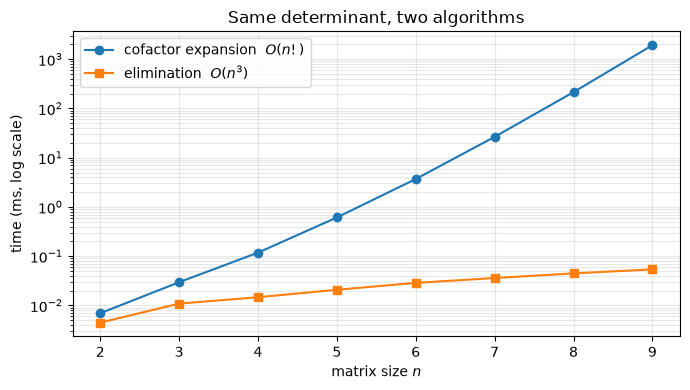

In [6]:
plt.figure(figsize=(7, 4))
plt.semilogy(sizes, cof_times, "o-", label="cofactor expansion  $O(n!)$")
plt.semilogy(sizes, elim_times, "s-", label="elimination  $O(n^3)$")
plt.xlabel("matrix size $n$"); plt.ylabel("time (ms, log scale)")
plt.title("Same determinant, two algorithms"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

The cofactor expansion is a fine *definition* and a hopeless *algorithm*. This
is a recurring pattern in linear algebra: the formula that explains what a
quantity means is rarely the one you compute with, and confusing the two is how
people end up waiting years for a determinant.

## II.c The property that makes determinants worth having

🧠 **The intuition.** A matrix scales volume by a fixed factor, and composing
two transformations compounds their factors: the second rescales whatever the
first produced. The most useful determinant identity is just that sentence,
written down.

📐 **The math.** $\det(AB) = \det(A)\det(B)$.

Read geometrically it is obvious: do one transformation that scales volume by 3,
then one that scales by $-2$, and volume is scaled by $-6$. Read algebraically
it is remarkable, since matrix multiplication mixes every entry with every other.
It also gives $\det(A^{-1}) = 1/\det(A)$ for free.

💻 **The code.** Check the identity numerically on random matrices, along with
the inverse, transpose, and scaling rules that ride along with it.

In [7]:
P, Q = rng.normal(size=(4, 4)), rng.normal(size=(4, 4))
print(f"det(P)·det(Q) = {np.linalg.det(P) * np.linalg.det(Q): .6f}")
print(f"det(PQ)       = {np.linalg.det(P @ Q): .6f}")
print(f"det(P^-1)     = {np.linalg.det(np.linalg.inv(P)): .6f}   1/det(P) = {1/np.linalg.det(P): .6f}")
print(f"det(P^T)      = {np.linalg.det(P.T): .6f}   det(P) = {np.linalg.det(P): .6f}")
print(f"det(3P)       = {np.linalg.det(3 * P): .6f}   3^4·det(P) = {3**4 * np.linalg.det(P): .6f}")
print("\nThat last line is the one people get wrong: scaling a matrix by c scales")
print("its determinant by c^n, because it stretches all n dimensions at once.")

det(P)·det(Q) =  8.920656
det(PQ)       =  8.920656
det(P^-1)     = -0.144981   1/det(P) = -0.144981
det(P^T)      = -6.897444   det(P) = -6.897444
det(3P)       = -558.692975   3^4·det(P) = -558.692975

That last line is the one people get wrong: scaling a matrix by c scales
its determinant by c^n, because it stretches all n dimensions at once.


---
# Module III — The Inverse

## III.a Undoing a transformation

🧠 **The intuition.** $A^{-1}$ is the transformation that puts everything back.
It exists exactly when nothing was lost on the way out, which is to say when $A$
is one-to-one and onto. If $A$ flattened the plane onto a line, infinitely many
inputs landed on each output and no rule can decide which one to send back.

📐 **The math.** For a square $A$, the following are **all the same statement**:

$$ A^{-1} \text{ exists} \iff \det A \neq 0 \iff \text{rank}(A) = n \iff
N(A) = \{\mathbf{0}\} \iff \text{columns are a basis} \iff A\mathbf{x} = \mathbf{b}
\text{ has exactly one solution for every } \mathbf{b} $$

Every chapter so far contributed one link in that chain. For $2 \times 2$ there
is a closed form worth remembering:

$$ \begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1}
= \frac{1}{ad - bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix} $$

and the $1/\det$ out front is the whole story: as the determinant approaches
zero, the entries of the inverse blow up.

💻 **The code.** Build it by Gauss–Jordan: row-reduce $[A \mid I]$ and the
identity block turns into $A^{-1}$.

In [8]:
def inverse_by_elimination(M, tol=1e-12):
    """Row-reduce [A | I] to [I | A^-1]. Returns None if A is singular."""
    A = np.array(M, dtype=float, copy=True)
    n = A.shape[0]
    aug = np.column_stack([A, np.eye(n)])
    for col in range(n):
        p = col + int(np.argmax(np.abs(aug[col:, col])))
        if abs(aug[p, col]) < tol:
            return None                                    # singular
        aug[[col, p]] = aug[[p, col]]
        aug[col] /= aug[col, col]
        for i in range(n):
            if i != col:
                aug[i] -= aug[i, col] * aug[col]
    return aug[:, n:]


A2 = np.array([[2.0, -1.0], [0.5, 1.0]])
Ainv = inverse_by_elimination(A2)
print("A =\n", A2, "\n\nA^-1 (by elimination) =\n", Ainv)
print("\nformula (1/det)[[d, -b], [-c, a]] =\n",
      np.array([[A2[1,1], -A2[0,1]], [-A2[1,0], A2[0,0]]]) / np.linalg.det(A2))
print("\nA @ A^-1 = I:", np.allclose(A2 @ Ainv, np.eye(2)))

singular = np.array([[1.0, 2.0], [2.0, 4.0]])
print("\ninverse of a singular matrix:", inverse_by_elimination(singular),
      f"  (det = {np.linalg.det(singular):.1f})")

A =
 [[ 2.  -1. ]
 [ 0.5  1. ]] 

A^-1 (by elimination) =
 [[ 0.4  0.4]
 [-0.2  0.8]]

formula (1/det)[[d, -b], [-c, a]] =
 [[ 0.4  0.4]
 [-0.2  0.8]]

A @ A^-1 = I: True

inverse of a singular matrix: None   (det = 0.0)


---
# Module IV — Why You Should Almost Never Compute an Inverse

## IV.a `solve` versus `inv`

🧠 **The intuition.** The textbook formula — apply the inverse to $\mathbf{b}$
— is a true statement about mathematics and bad advice about computation. Forming $A^{-1}$ does the work of
solving $n$ systems (one per column of $I$) and then throws away the structure,
leaving you to do a matrix–vector multiply on top. Elimination solves the system
you actually asked about, once.

📐 **The math.** Computing $\mathbf{x} = A^{-1}\mathbf{b}$ and solving
$A\mathbf{x} = \mathbf{b}$ by elimination are both $O(n^3)$, but the constants
differ by roughly a factor of 3, and, more importantly, the round-off behaviour differs: `solve` gives a
result with a small *backward* error, while `inv` accumulates error twice.

💻 **The code.** Time and accuracy, on the same systems.

In [9]:
n = 600        # <- knob
Abig = rng.normal(size=(n, n))
bbig = rng.normal(size=n)

t0 = time.perf_counter(); x_solve = np.linalg.solve(Abig, bbig);     t_solve = time.perf_counter() - t0
t0 = time.perf_counter(); x_inv = np.linalg.inv(Abig) @ bbig;        t_inv = time.perf_counter() - t0

print(f"solve(A, b)   {t_solve*1e3:8.2f} ms   residual ||Ax - b|| = {np.linalg.norm(Abig @ x_solve - bbig):.3e}")
print(f"inv(A) @ b    {t_inv*1e3:8.2f} ms   residual ||Ax - b|| = {np.linalg.norm(Abig @ x_inv - bbig):.3e}")
print(f"\ninv is {t_inv/t_solve:.1f}x slower here, and its residual is "
      f"{np.linalg.norm(Abig @ x_inv - bbig)/np.linalg.norm(Abig @ x_solve - bbig):.1f}x larger.")

solve(A, b)       8.35 ms   residual ||Ax - b|| = 9.736e-12
inv(A) @ b       24.07 ms   residual ||Ax - b|| = 1.614e-11

inv is 2.9x slower here, and its residual is 1.7x larger.


## IV.b The condition number: how much your errors get amplified

🧠 **The intuition.** Some systems are delicate. Nudge $\mathbf{b}$ in the tenth
decimal place and the solution moves in the first. That is not the algorithm's
fault. It is a property of the matrix, and it has a name.

📐 **The math.** The **condition number** is

$$ \kappa(A) = \frac{\sigma_{\max}}{\sigma_{\min}} $$

the ratio of the largest to smallest singular value (Chapter 2 met
$\sigma_{\min}$ as "distance to the nearest singular matrix"; Chapter 9 builds
them). It bounds the damage:

$$ \frac{\|\Delta \mathbf{x}\|}{\|\mathbf{x}\|} \;\le\; \kappa(A)\,\frac{\|\Delta \mathbf{b}\|}{\|\mathbf{b}\|} $$

A perfectly conditioned matrix has $\kappa = 1$. A rule of thumb: with double
precision (about 16 digits), a condition number of $10^k$ costs you roughly $k$
of them.

💻 **The code.** The **Hilbert matrix** $H_{ij} = 1/(i+j-1)$ is the classic
horror: innocent-looking, and catastrophically ill-conditioned. Perturb
$\mathbf{b}$ by one part in $10^{10}$ and watch.

In [10]:
def hilbert(n):
    i = np.arange(1, n + 1)
    return 1.0 / (i[:, None] + i[None, :] - 1)

print(f"{'n':>3} {'cond(H)':>12} {'input change':>14} {'output change':>15} {'amplification':>15}")
for n in [4, 6, 8, 10, 12]:
    H = hilbert(n)
    x_true = np.ones(n)
    bvec = H @ x_true
    db = rng.normal(size=n); db *= 1e-10 * np.linalg.norm(bvec) / np.linalg.norm(db)
    x_pert = np.linalg.solve(H, bvec + db)

    rel_in = np.linalg.norm(db) / np.linalg.norm(bvec)
    rel_out = np.linalg.norm(x_pert - x_true) / np.linalg.norm(x_true)
    print(f"{n:>3} {np.linalg.cond(H):>12.2e} {rel_in:>14.1e} {rel_out:>15.1e} {rel_out/rel_in:>15.1e}")

print("\nThe amplification tracks the condition number, exactly as the bound predicts.")
print("By n = 12 a perturbation in the 10th digit has destroyed the answer entirely.")

  n      cond(H)   input change   output change   amplification
  4     1.55e+04        1.0e-10         6.9e-07         6.9e+03
  6     1.50e+07        1.0e-10         5.6e-04         5.6e+06
  8     1.53e+10        1.0e-10         4.4e-01         4.4e+09
 10     1.60e+13        1.0e-10         3.3e+02         3.3e+12
 12     1.62e+16        1.0e-10         1.0e+05         1.0e+15

The amplification tracks the condition number, exactly as the bound predicts.
By n = 12 a perturbation in the 10th digit has destroyed the answer entirely.


This is the most practically useful number in numerical linear algebra. It tells
you, before you compute anything, how much of your input precision will survive,
and no clever algorithm can rescue a badly conditioned problem, because the
sensitivity lives in the matrix rather than in the method.

---
# Module V — The Honest Verdict on `det`

🧠 **The intuition.** "Check whether the determinant is zero to see if $A$ is invertible"
is standard advice, and in floating point it is close to useless. Two reasons,
both easy to demonstrate:

1. The determinant scales like $c^n$. A perfectly harmless matrix, multiplied by
   $0.1$, has a determinant $10^{-n}$ times smaller, so it ends up with a tiny
   determinant and perfect conditioning.
2. A genuinely dangerous matrix can have a determinant of respectable size.

📐 **The math.** The determinant is the *product* of the singular values;
invertibility is governed by the *smallest* one. A product tells you almost
nothing about its smallest factor.

💻 **The code.** Four matrices. Compare what `det` says with what $\kappa$ says.

In [11]:
cases = {
    "identity × 0.1 (20x20)":     0.1 * np.eye(20),
    "well-conditioned random":    np.linalg.qr(rng.normal(size=(20, 20)))[0],
    "Hilbert 12x12":              hilbert(12),
    "nearly singular 2x2":        np.array([[1.0, 1.0], [1.0, 1.0 + 1e-12]]),
}

print(f"{'matrix':<28} {'det':>12} {'cond':>12}   verdict")
for name, Mz in cases.items():
    d, k = np.linalg.det(Mz), np.linalg.cond(Mz)
    verdict = "SAFE to solve" if k < 1e8 else "DANGEROUS"
    print(f"{name:<28} {d:>12.2e} {k:>12.2e}   {verdict}")

print("\nRow 1: determinant 1e-20, condition number 1, as safe as a matrix can be.")
print("Row 3: determinant ~1e-78, and genuinely dangerous.")
print("Row 4: determinant 1e-12, condition number 4e12, also dangerous.")
print("\nThe determinants of rows 1 and 3 differ by 58 orders of magnitude,")
print("and tell you nothing useful. The condition numbers separate them correctly.")

matrix                                det         cond   verdict
identity × 0.1 (20x20)           1.00e-20     1.00e+00   SAFE to solve
well-conditioned random         -1.00e+00     1.00e+00   SAFE to solve
Hilbert 12x12                    2.72e-78     1.62e+16   DANGEROUS
nearly singular 2x2              1.00e-12     4.00e+12   DANGEROUS

Row 1: determinant 1e-20, condition number 1, as safe as a matrix can be.
Row 3: determinant ~1e-78, and genuinely dangerous.
Row 4: determinant 1e-12, condition number 4e12, also dangerous.

The determinants of rows 1 and 3 differ by 58 orders of magnitude,
and tell you nothing useful. The condition numbers separate them correctly.


**So what is the determinant actually for?**

Geometry, mostly. It is the volume scale factor, which is why it turns up in the
change-of-variables formula for multiple integrals (the Jacobian determinant), in
computer graphics, and in probability, where the normalising constant of a
multivariate Gaussian is $\sqrt{\det \Sigma}$. In theory it gives the
characteristic polynomial $\det(A - \lambda I) = 0$, which *defines* eigenvalues
and opens Chapter 8. And for a $2 \times 2$ or $3 \times 3$ by hand, it is
perfect.

What it is *not* is a numerical test for invertibility. For that, use
`np.linalg.cond`, or look at $\sigma_{\min}$ directly.

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| Monte Carlo areas matching $\lvert\det\rvert$ | The determinant *is* the volume scale factor, and everything else follows from that |
| Rotation and shear both giving $\det = 1$ | Area is not shape: leaning a parallelogram over changes neither base nor height |
| $\det = 0$ flattening the square | Zero determinant = collapse = information destroyed = no inverse |
| `det_by_elimination` vs `det_by_cofactors` | $O(n^3)$ vs $O(n!)$: the formula that defines a quantity is rarely the one you compute with |
| $\det(AB) = \det A \det B$, $\det(cA) = c^n \det A$ | Composition multiplies volume factors; scaling stretches all $n$ dimensions at once |
| `inverse_by_elimination` on $[A \mid I]$ | The inverse is just elimination run against $n$ right-hand sides |
| The equivalence chain | Invertible, $\det \neq 0$, full rank, trivial null space, columns a basis: one fact in six costumes |
| `solve` beating `inv` in time and accuracy | Never write `inv(A) @ b`. Ask the question you actually have |
| Hilbert matrices amplifying error by $\kappa$ | Conditioning is a property of the problem; no algorithm can undo it |
| $\det = 10^{-20}$ with $\kappa = 1$ | **`det` is not a singularity detector.** Use the condition number |

**Where the course goes from here.** Chapter 5 ended with a system that had no
solution and a plot with a line through it anyway, and this chapter has now
supplied the vocabulary to say what went wrong: $\mathbf{b}$ was outside the
column space, and no amount of inverting will change that.

**Chapter 7** answers the question that is actually useful in that situation,
*what is the closest thing to a solution?*, and the answer turns on a single
geometric idea that has been circling since Chapter 5's four subspaces:
**perpendicularity**. It gives us projection, orthonormal bases, $QR$, and least
squares, which is to say linear regression, derived rather than asserted.